# 📘 Data Analytics Lab – Assignment-1
- Data Cleaning & Preprocessing

##  Step 1: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## Step 2: Load & Understand the Dataset
`car_data.csv`

In [4]:
df=pd.read_csv("data.csv")

In [10]:
print(df.sample(5))
print(df['Make'].value_counts())
print(df.shape)
print(df.columns)

         Make                Model  Year             Engine Fuel Type  \
443       BMW             4 Series  2016  premium unleaded (required)   
10156  Toyota                 T100  1997             regular unleaded   
8129    Dodge            Ram Cargo  2001             regular unleaded   
6181      GMC                Jimmy  2001             regular unleaded   
9411      GMC  Sierra Classic 1500  1999             regular unleaded   

       Engine HP  Engine Cylinders Transmission Type     Driven_Wheels  \
443        240.0               4.0         AUTOMATIC   all wheel drive   
10156      190.0               6.0            MANUAL  four wheel drive   
8129       225.0               8.0         AUTOMATIC  rear wheel drive   
6181       190.0               6.0         AUTOMATIC  four wheel drive   
9411       200.0               8.0         AUTOMATIC  rear wheel drive   

       Number of Doors Market Category Vehicle Size        Vehicle Style  \
443                2.0          Luxury  

## Step 3: Filter for Volkswagen Cars Only

In [15]:
volkswagon_df=df[df['Make']=='Volkswagen']
print(volkswagon_df)
print(volkswagon_df.shape)

             Make               Model  Year                Engine Fuel Type  \
1792   Volkswagen  Beetle Convertible  2014                regular unleaded   
1793   Volkswagen  Beetle Convertible  2014  premium unleaded (recommended)   
1794   Volkswagen  Beetle Convertible  2014  premium unleaded (recommended)   
1795   Volkswagen  Beetle Convertible  2014                regular unleaded   
1796   Volkswagen  Beetle Convertible  2014                          diesel   
...           ...                 ...   ...                             ...   
11188  Volkswagen             Vanagon  1990                regular unleaded   
11189  Volkswagen             Vanagon  1991                regular unleaded   
11190  Volkswagen             Vanagon  1991                regular unleaded   
11191  Volkswagen             Vanagon  1991                regular unleaded   
11192  Volkswagen             Vanagon  1991                regular unleaded   

       Engine HP  Engine Cylinders Transmission Typ

In [16]:
# Check missing values
print(volkswagon_df.isnull().sum())

Make                   0
Model                  0
Year                   0
Engine Fuel Type       0
Engine HP              0
Engine Cylinders       4
Transmission Type      0
Driven_Wheels          0
Number of Doors        0
Market Category      224
Vehicle Size           0
Vehicle Style          0
highway MPG            0
city mpg               0
Popularity             0
MSRP                   0
dtype: int64


###  Remove rows with null values

In [19]:
volkswagon_df=volkswagon_df.dropna()
print(volkswagon_df.shape)

(581, 16)


## Step 4: Select Features : 'Engine HP', 'MSRP'

In [21]:
volkswagon_df=volkswagon_df[['Engine HP','MSRP']]


      Engine HP   MSRP
5625      200.0  26875
1850      150.0  30775


In [22]:
print(volkswagon_df.sample(2))

      Engine HP   MSRP
5660      200.0  29295
2419      200.0  37820


Dataframe X contais 'Engine HP'
Dataframe Y contains 'MSRP'

In [25]:
x=np.array(volkswagon_df[['Engine HP']])
print(x.shape)

(581, 1)


In [24]:
y=np.array(volkswagon_df[['MSRP']])
(y.shape)

(581, 1)

## Step 5: Scatter Plot – HP vs Price

Text(0, 0.5, 'MSRP')

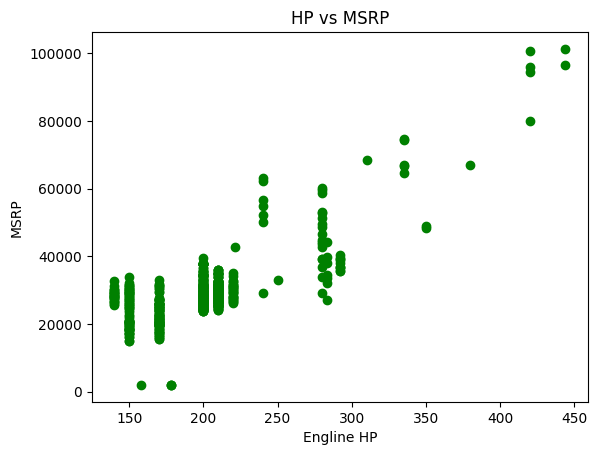

In [27]:
plt.scatter(x,y,color="Green")
plt.title("HP vs MSRP")
plt.xlabel("Engline HP")
plt.ylabel("MSRP")
plt.show()

## Step 6: Train-Test Split : 25% for testing and 75% for training

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=15)
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

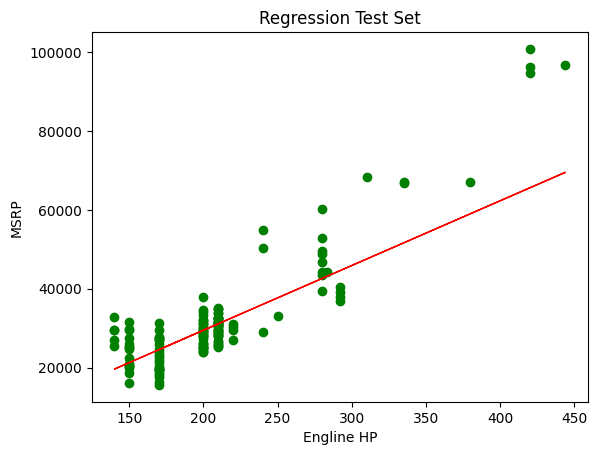

In [44]:
plt.scatter(x_test,y_test,color="Green")
plt.plot(x_train, lr.predict(x_train), color="red", linewidth=1)
plt.title("Regression Test Set")
plt.xlabel("Engline HP")
plt.ylabel("MSRP")
plt.show()